# Visualización de la Función de Tarea 1

## Función Multi-Modal con Gaussianas Invertidas (4 Mínimos Locales)

$$f(x, y) = -e^{-(x-1)^2-(y-1)^2} - 0.8e^{-(1.5*x+1.5)^2-(y+0.5)^2} - 0.9e^{-(x-2)^2-(2*y+2)^2} - 1.1e^{-(1.5*x-4.5)^2-(0.7*y-2)^2}$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir la función con 4 mínimos locales (gaussianas invertidas)
def f(x, y):
    return (-np.exp(-(x - 1)**2 - (y - 1)**2) - 
            0.8 * np.exp(-(1.5*x + 1.5)**2 - (y + 0.5)**2) - 
            0.9 * np.exp(-(x - 2)**2 - (2*y + 2)**2) - 
            1.1 * np.exp(-(1.5*x - 4.5)**2 - (0.7*y - 2)**2))

# Crear malla de puntos
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

print(f"Valor mínimo de f en la malla: {Z.min():.4f}")
print(f"Valor máximo de f en la malla: {Z.max():.4f}")

Valor mínimo de f en la malla: -1.1003
Valor máximo de f en la malla: -0.0000


## Gráfico 3D

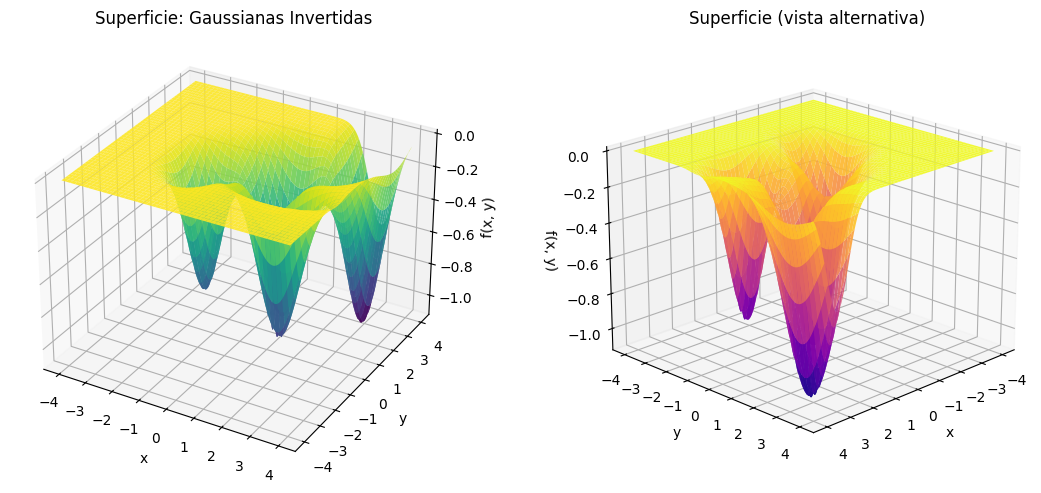

In [12]:
fig = plt.figure(figsize=(12, 5))

# Gráfico 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.set_title('Superficie: Gaussianas Invertidas')

# Vista alternativa con ángulo diferente
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x, y)')
ax2.set_title('Superficie (vista alternativa)')
ax2.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## Curvas de Nivel

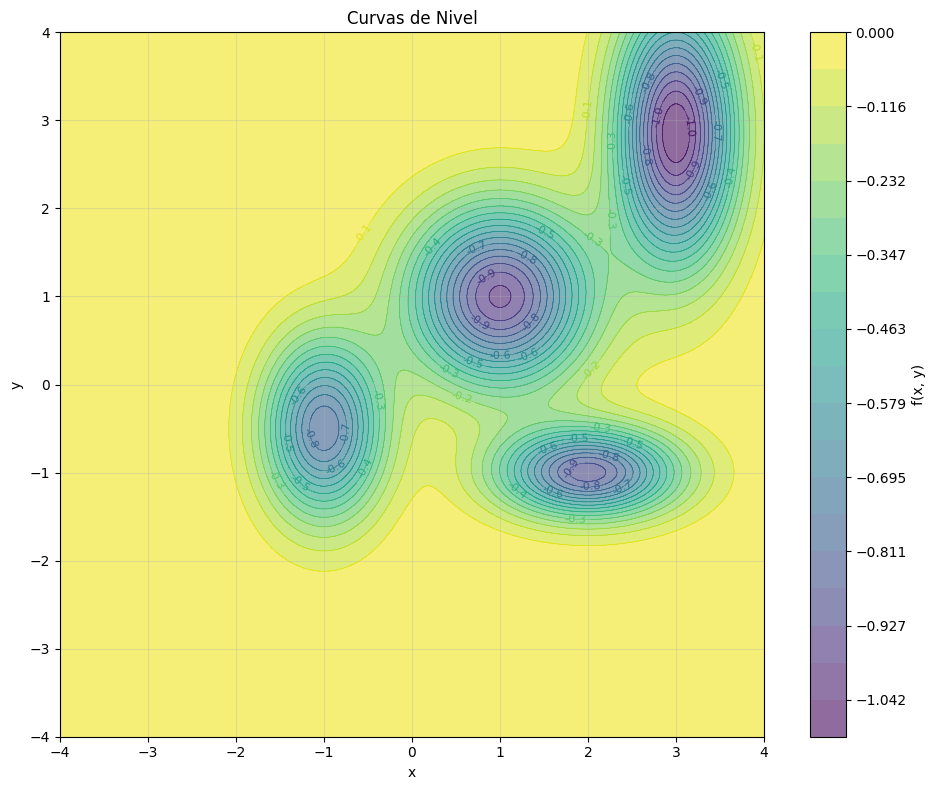

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

# Curvas de nivel
levels = np.linspace(Z.min(), Z.max(), 20)
contours = ax.contour(X, Y, Z, levels=levels, cmap='viridis', linewidths=0.5)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Relleno de contornos
contourf = ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.6)

# Barra de color
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label('f(x, y)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Curvas de Nivel')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Información de la Función

In [14]:
print("=" * 60)
print("INFORMACIÓN DE LA FUNCIÓN (GAUSSIANAS INVERTIDAS)")
print("=" * 60)
print(f"\nDominio analizado: x ∈ [-4, 4], y ∈ [-4, 4]")
print(f"\nValor mínimo encontrado: {Z.min():.6f}")
print(f"Valor máximo encontrado: {Z.max():.6f}")
print(f"Rango de valores: {Z.max() - Z.min():.6f}")

# Encontrar índice del mínimo
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
x_min = X[min_idx]
y_min = Y[min_idx]
f_min = Z.min()

print(f"\nMínimo encontrado en:")
print(f"  x = {x_min:.6f}")
print(f"  y = {y_min:.6f}")
print(f"  f(x, y) = {f_min:.6f}")

print(f"\nNota: Esta función es la suma de 4 gaussianas invertidas (negativas),")
print(f"cada una centrada en un punto diferente. Esto crea 4 valles locales")
print(f"bien diferenciados y profundos, ideales para el análisis de métodos")
print(f"de optimización multívariable.")


INFORMACIÓN DE LA FUNCIÓN (GAUSSIANAS INVERTIDAS)

Dominio analizado: x ∈ [-4, 4], y ∈ [-4, 4]

Valor mínimo encontrado: -1.100295
Valor máximo encontrado: -0.000000
Rango de valores: 1.100295

Mínimo encontrado en:
  x = 3.010033
  y = 2.849498
  f(x, y) = -1.100295

Nota: Esta función es la suma de 4 gaussianas invertidas (negativas),
cada una centrada en un punto diferente. Esto crea 4 valles locales
bien diferenciados y profundos, ideales para el análisis de métodos
de optimización multívariable.


## Parte B, C, D: Implementación de los 3 Métodos de Optimización

In [15]:
# Calcular el gradiente numéricamente (derivadas parciales)
def gradient(x, y, h=1e-5):
    """Calcula el gradiente ∇f = (∂f/∂x, ∂f/∂y) usando diferencias finitas"""
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([df_dx, df_dy])

# Calcular la matriz Hessiana numéricamente
def hessian(x, y, h=1e-4):
    """Calcula la matriz Hessiana H = [[∂²f/∂x², ∂²f/∂xy], [∂²f/∂yx, ∂²f/∂y²]]"""
    # Segundas derivadas parciales
    f_xx = (f(x + h, y) - 2*f(x, y) + f(x - h, y)) / (h**2)
    f_yy = (f(x, y + h) - 2*f(x, y) + f(x, y - h)) / (h**2)
    f_xy = (f(x + h, y + h) - f(x + h, y - h) - f(x - h, y + h) + f(x - h, y - h)) / (4 * h**2)
    
    return np.array([[f_xx, f_xy], 
                     [f_xy, f_yy]])

print("Funciones de gradiente y Hessiano definidas ✓")

Funciones de gradiente y Hessiano definidas ✓


In [16]:
# MÉTODO B: Gradiente Descendente con Paso Fijo
def gradient_descent_fixed_step(x0, y0, alpha=0.01, max_iter=500, tol=1e-6):
    """
    Gradiente descendente con tamaño de paso fijo
    
    Parámetros:
    - (x0, y0): punto inicial
    - alpha: tamaño de paso fijo
    - max_iter: máximo de iteraciones
    - tol: tolerancia para convergencia
    """
    trajectory = [(x0, y0)]
    x, y = x0, y0
    
    for i in range(max_iter):
        grad = gradient(x, y)
        grad_norm = np.linalg.norm(grad)
        
        if grad_norm < tol:
            break
        
        # Actualizar: x_new = x - alpha * ∇f
        x = x - alpha * grad[0]
        y = y - alpha * grad[1]
        trajectory.append((x, y))
    
    return x, y, f(x, y), i+1, trajectory

# MÉTODO C: Gradiente Descendente con Dirección Normalizada
def gradient_descent_normalized(x0, y0, alpha=0.1, max_iter=500, tol=1e-6):
    """
    Gradiente descendente con dirección normalizada (paso unitario en dirección del gradiente)
    
    Parámetros:
    - (x0, y0): punto inicial
    - alpha: tamaño de paso (multiplicado por dirección normalizada)
    - max_iter: máximo de iteraciones
    - tol: tolerancia para convergencia
    """
    trajectory = [(x0, y0)]
    x, y = x0, y0
    
    for i in range(max_iter):
        grad = gradient(x, y)
        grad_norm = np.linalg.norm(grad)
        
        if grad_norm < tol:
            break
        
        # Normalizar gradiente y actualizar
        grad_normalized = grad / grad_norm
        x = x - alpha * grad_normalized[0]
        y = y - alpha * grad_normalized[1]
        trajectory.append((x, y))
    
    return x, y, f(x, y), i+1, trajectory

# MÉTODO D: Newton-Raphson para encontrar puntos críticos (∇f = 0)
def newton_raphson_critical_points(x0, y0, max_iter=100, tol=1e-6):
    """
    Newton-Raphson para resolver ∇f(x,y) = 0
    Usa el método de Newton multivariable:
    
    [x]_new = [x]_old - H^(-1) * ∇f
    [y]_new = [y]_old
    
    donde H es la matriz Hessiana
    """
    trajectory = [(x0, y0)]
    x, y = x0, y0
    
    for i in range(max_iter):
        grad = gradient(x, y)
        grad_norm = np.linalg.norm(grad)
        
        if grad_norm < tol:
            break
        
        # Calcular Hessiano
        H = hessian(x, y)
        
        # Evitar singularidad
        try:
            H_inv = np.linalg.inv(H)
        except np.linalg.LinAlgError:
            # Si la matriz es singular, añadir un pequeño valor a la diagonal
            H += np.eye(2) * 1e-6
            H_inv = np.linalg.inv(H)
        
        # Actualizar: [x, y]_new = [x, y]_old - H^(-1) * ∇f
        delta = H_inv @ grad
        x = x - delta[0]
        y = y - delta[1]
        trajectory.append((x, y))
    
    return x, y, f(x, y), i+1, trajectory

print("Métodos de optimización definidos ✓")

Métodos de optimización definidos ✓


In [17]:
# 4 PUNTOS ESTRATÉGICOS seleccionados en diferentes regiones del dominio
puntos_iniciales = {
    'P1 (arriba-izq)': (-3, 3),
    'P2 (arriba-der)': (3, 3),
    'P3 (abajo-izq)': (-3, -3),
    'P4 (centro)': (0, 0)
}

# Ejecutar los 3 métodos desde cada punto inicial
resultados = {}  # Guardar resultados para comparación

for nombre_punto, (x0, y0) in puntos_iniciales.items():
    print(f"\n{'='*60}")
    print(f"Punto inicial: {nombre_punto} = ({x0}, {y0})")
    print(f"{'='*60}")
    
    # Método B: Gradiente Descendente Paso Fijo
    x_b, y_b, f_b, iter_b, traj_b = gradient_descent_fixed_step(x0, y0, alpha=0.01)
    print(f"\n[B] Gradiente Descendente Paso Fijo:")
    print(f"    Mínimo encontrado: ({x_b:.4f}, {y_b:.4f})")
    print(f"    Valor f: {f_b:.6f}")
    print(f"    Iteraciones: {iter_b}")
    
    # Método C: Gradiente Descendente Normalizado
    x_c, y_c, f_c, iter_c, traj_c = gradient_descent_normalized(x0, y0, alpha=0.1)
    print(f"\n[C] Gradiente Descendente Normalizado:")
    print(f"    Mínimo encontrado: ({x_c:.4f}, {y_c:.4f})")
    print(f"    Valor f: {f_c:.6f}")
    print(f"    Iteraciones: {iter_c}")
    
    # Método D: Newton-Raphson
    x_d, y_d, f_d, iter_d, traj_d = newton_raphson_critical_points(x0, y0)
    print(f"\n[D] Newton-Raphson:")
    print(f"    Punto crítico encontrado: ({x_d:.4f}, {y_d:.4f})")
    print(f"    Valor f: {f_d:.6f}")
    print(f"    Iteraciones: {iter_d}")
    
    # Guardar resultados
    resultados[nombre_punto] = {
        'P0': (x0, y0),
        'GD_Paso': {'coords': (x_b, y_b), 'f': f_b, 'iter': iter_b, 'traj': traj_b},
        'GD_Norm': {'coords': (x_c, y_c), 'f': f_c, 'iter': iter_c, 'traj': traj_c},
        'Newton': {'coords': (x_d, y_d), 'f': f_d, 'iter': iter_d, 'traj': traj_d}
    }

print(f"\n{'='*60}\nEjecución completada ✓\n{'='*60}")



Punto inicial: P1 (arriba-izq) = (-3, 3)

[B] Gradiente Descendente Paso Fijo:
    Mínimo encontrado: (-3.0000, 3.0000)
    Valor f: -0.000000
    Iteraciones: 1

[C] Gradiente Descendente Normalizado:
    Mínimo encontrado: (-3.0000, 3.0000)
    Valor f: -0.000000
    Iteraciones: 1

[D] Newton-Raphson:
    Punto crítico encontrado: (-3.0000, 3.0000)
    Valor f: -0.000000
    Iteraciones: 1

Punto inicial: P2 (arriba-der) = (3, 3)

[B] Gradiente Descendente Paso Fijo:
    Mínimo encontrado: (2.9995, 2.8558)
    Valor f: -1.100585
    Iteraciones: 500

[C] Gradiente Descendente Normalizado:
    Mínimo encontrado: (3.0649, 2.8549)
    Valor f: -1.090088
    Iteraciones: 500

[D] Newton-Raphson:
    Punto crítico encontrado: (2.9995, 2.8551)
    Valor f: -1.100585
    Iteraciones: 3

Punto inicial: P3 (abajo-izq) = (-3, -3)

[B] Gradiente Descendente Paso Fijo:
    Mínimo encontrado: (-3.0000, -3.0000)
    Valor f: -0.000000
    Iteraciones: 500

[C] Gradiente Descendente Normalizado:


## Comparación Visual de Trayectorias

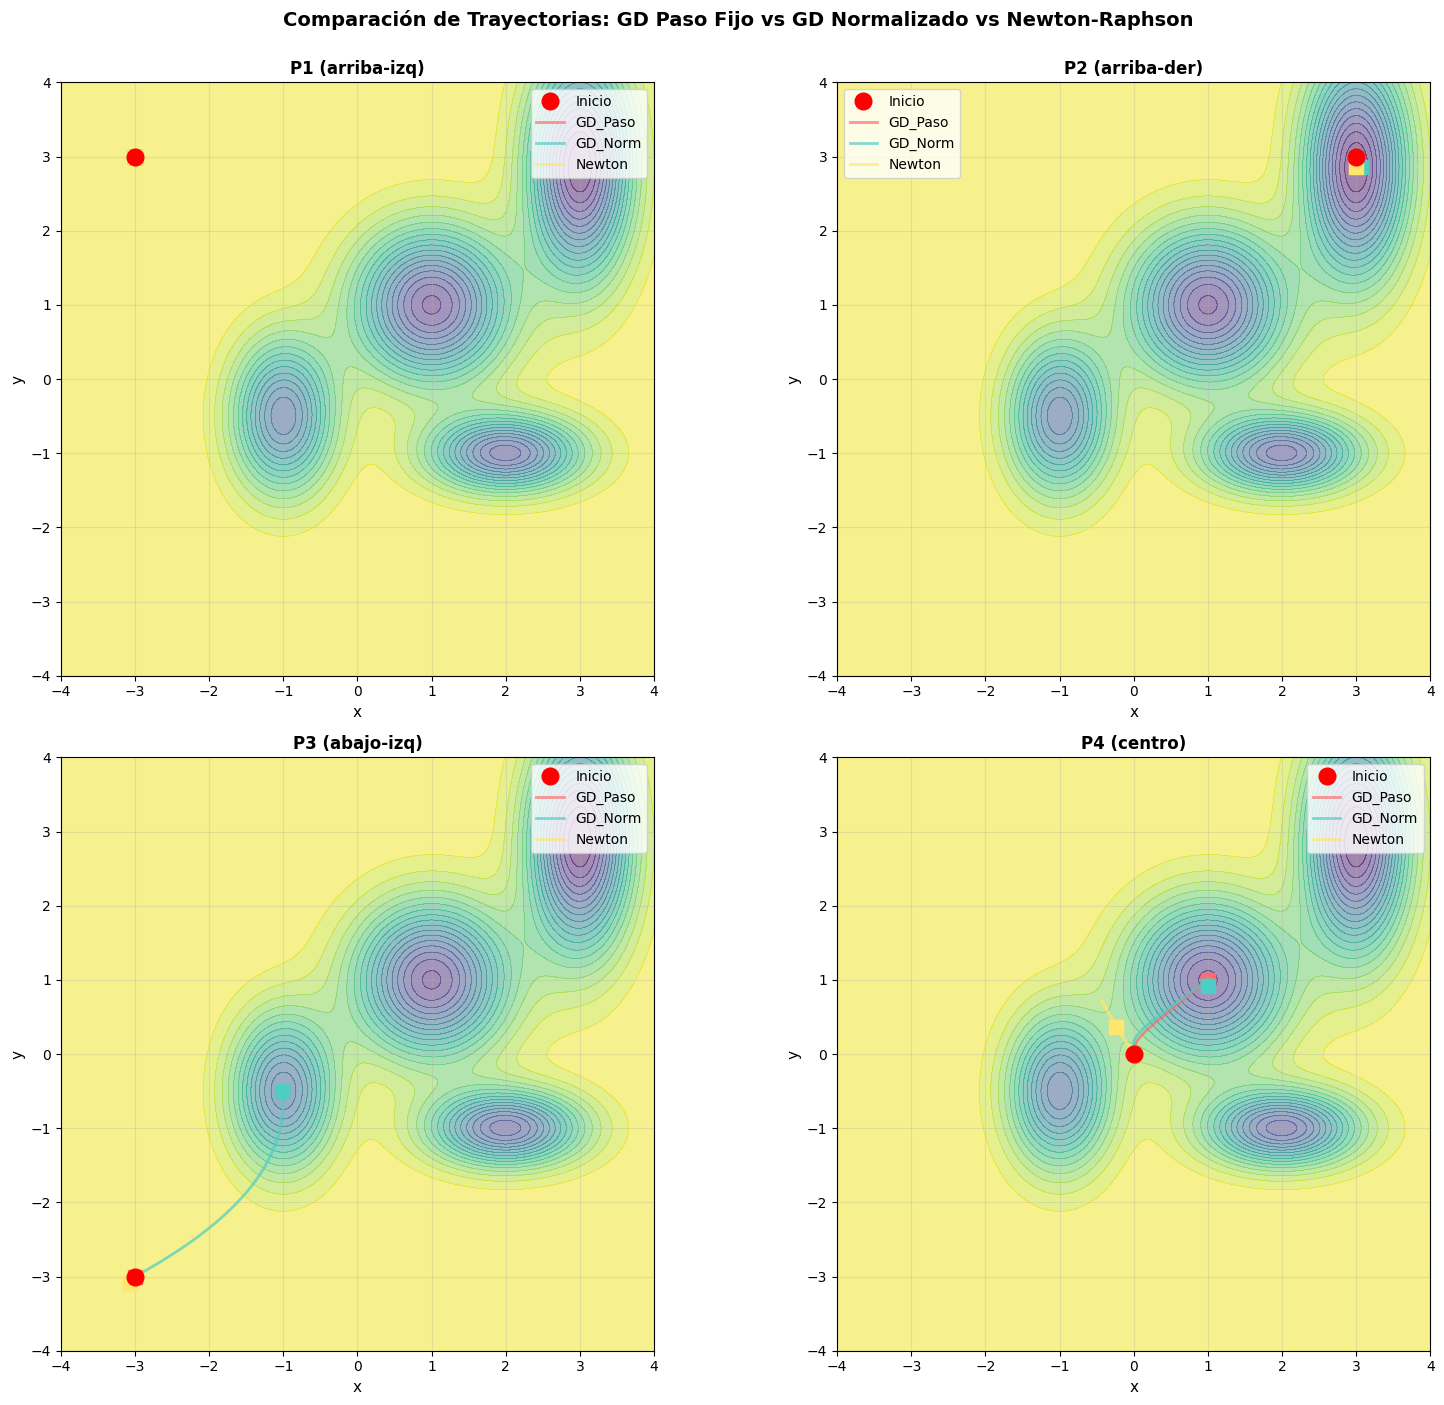

In [18]:
# Visualizar las trayectorias de los 3 métodos en curvas de nivel
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Colores para cada método
colores = {
    'GD_Paso': '#FF6B6B',  # Rojo
    'GD_Norm': '#4ECDC4',  # Teal
    'Newton': '#FFE66D'    # Amarillo
}

for idx, (nombre_punto, (x0, y0)) in enumerate(puntos_iniciales.items()):
    ax = axes[idx]
    
    # Dibujar curvas de nivel
    levels = np.linspace(Z.min(), Z.max(), 20)
    contourf = ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contour(X, Y, Z, levels=levels, cmap='viridis', linewidths=0.3, alpha=0.5)
    
    # Punto inicial
    ax.plot(x0, y0, 'o', color='red', markersize=12, label='Inicio', zorder=5)
    
    # Trayectorias de los 3 métodos
    for metodo in ['GD_Paso', 'GD_Norm', 'Newton']:
        traj = resultados[nombre_punto][metodo]['traj']
        traj_array = np.array(traj)
        
        # Línea de trayectoria
        ax.plot(traj_array[:, 0], traj_array[:, 1], '-', 
                color=colores[metodo], linewidth=2, alpha=0.7, label=metodo)
        
        # Punto final
        ax.plot(traj_array[-1, 0], traj_array[-1, 1], 's', 
                color=colores[metodo], markersize=10)
    
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'{nombre_punto}', fontsize=12, fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    ax.set_aspect('equal')

plt.suptitle('Comparación de Trayectorias: GD Paso Fijo vs GD Normalizado vs Newton-Raphson', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Tabla de Resultados

In [19]:
# Crear tabla de resultados comparativos
import pandas as pd

# Construir datos para la tabla
datos_tabla = []

for nombre_punto in puntos_iniciales.keys():
    x0, y0 = resultados[nombre_punto]['P0']
    
    for metodo in ['GD_Paso', 'GD_Norm', 'Newton']:
        coords = resultados[nombre_punto][metodo]['coords']
        f_val = resultados[nombre_punto][metodo]['f']
        iteraciones = resultados[nombre_punto][metodo]['iter']
        
        datos_tabla.append({
            'Punto Inicial': nombre_punto,
            'Método': metodo.replace('GD_Paso', 'GD Paso Fijo').replace('GD_Norm', 'GD Normalizado').replace('Newton', 'Newton-Raphson'),
            'x_encontrado': f'{coords[0]:.4f}',
            'y_encontrado': f'{coords[1]:.4f}',
            'f(x,y)': f'{f_val:.6f}',
            'Iteraciones': iteraciones
        })

df = pd.DataFrame(datos_tabla)

# Mostrar tabla agrupada por punto inicial
print("\n" + "="*120)
print("TABLA RESUMEN DE RESULTADOS")
print("="*120)
for punto in puntos_iniciales.keys():
    print(f"\n{punto}:")
    print(df[df['Punto Inicial'] == punto][['Método', 'x_encontrado', 'y_encontrado', 'f(x,y)', 'Iteraciones']].to_string(index=False))

# Mostrar tabla completa
print("\n\nTABLA COMPLETA:")
print(df.to_string(index=False))


TABLA RESUMEN DE RESULTADOS

P1 (arriba-izq):
        Método x_encontrado y_encontrado    f(x,y)  Iteraciones
  GD Paso Fijo      -3.0000       3.0000 -0.000000            1
GD Normalizado      -3.0000       3.0000 -0.000000            1
Newton-Raphson      -3.0000       3.0000 -0.000000            1

P2 (arriba-der):
        Método x_encontrado y_encontrado    f(x,y)  Iteraciones
  GD Paso Fijo       2.9995       2.8558 -1.100585          500
GD Normalizado       3.0649       2.8549 -1.090088          500
Newton-Raphson       2.9995       2.8551 -1.100585            3

P3 (abajo-izq):
        Método x_encontrado y_encontrado    f(x,y)  Iteraciones
  GD Paso Fijo      -3.0000      -3.0000 -0.000000          500
GD Normalizado      -1.0188      -0.4961 -0.801202          500
Newton-Raphson      -3.0678      -3.0847 -0.000000            2

P4 (centro):
        Método x_encontrado y_encontrado    f(x,y)  Iteraciones
  GD Paso Fijo       0.9991       0.9993 -1.000034          500
GD Norma

## Análisis Comparativo

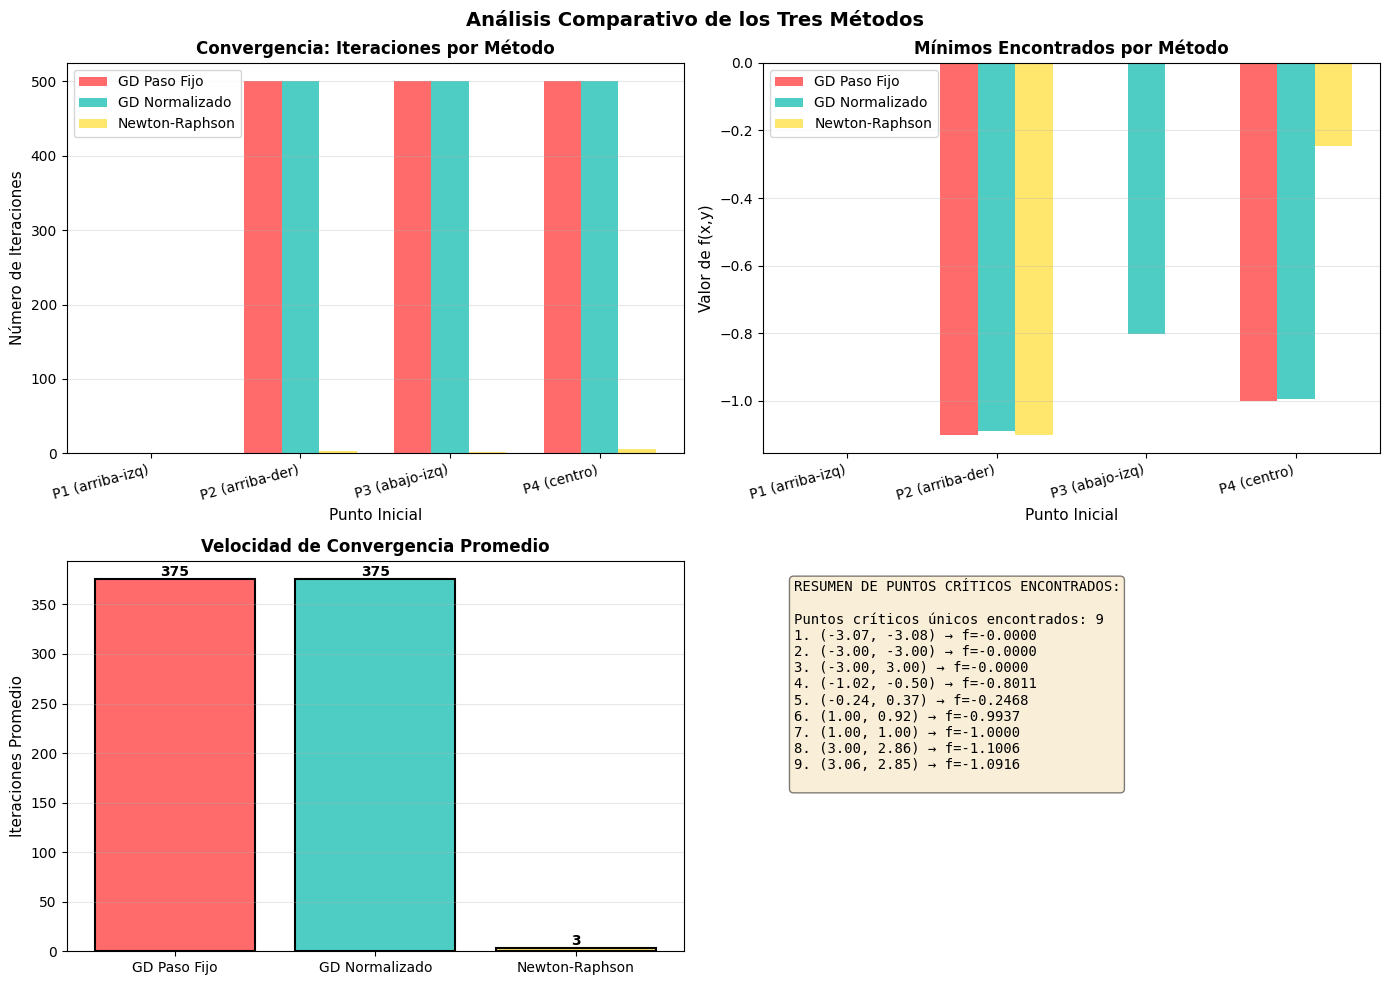


✓ Análisis visual completado


In [20]:
# Gráficos de análisis comparativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Número de iteraciones por método y punto inicial
ax = axes[0, 0]
nombres_puntos = list(puntos_iniciales.keys())
x_pos = np.arange(len(nombres_puntos))
width = 0.25

iter_gd_paso = [resultados[p]['GD_Paso']['iter'] for p in nombres_puntos]
iter_gd_norm = [resultados[p]['GD_Norm']['iter'] for p in nombres_puntos]
iter_newton = [resultados[p]['Newton']['iter'] for p in nombres_puntos]

ax.bar(x_pos - width, iter_gd_paso, width, label='GD Paso Fijo', color='#FF6B6B')
ax.bar(x_pos, iter_gd_norm, width, label='GD Normalizado', color='#4ECDC4')
ax.bar(x_pos + width, iter_newton, width, label='Newton-Raphson', color='#FFE66D')

ax.set_xlabel('Punto Inicial', fontsize=11)
ax.set_ylabel('Número de Iteraciones', fontsize=11)
ax.set_title('Convergencia: Iteraciones por Método', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_puntos, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 2. Valor de función encontrada
ax = axes[0, 1]
f_gd_paso = [resultados[p]['GD_Paso']['f'] for p in nombres_puntos]
f_gd_norm = [resultados[p]['GD_Norm']['f'] for p in nombres_puntos]
f_newton = [resultados[p]['Newton']['f'] for p in nombres_puntos]

ax.bar(x_pos - width, f_gd_paso, width, label='GD Paso Fijo', color='#FF6B6B')
ax.bar(x_pos, f_gd_norm, width, label='GD Normalizado', color='#4ECDC4')
ax.bar(x_pos + width, f_newton, width, label='Newton-Raphson', color='#FFE66D')

ax.set_xlabel('Punto Inicial', fontsize=11)
ax.set_ylabel('Valor de f(x,y)', fontsize=11)
ax.set_title('Mínimos Encontrados por Método', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(nombres_puntos, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Velocidad de convergencia (iteraciones promedio por método)
ax = axes[1, 0]
metodos = ['GD Paso Fijo', 'GD Normalizado', 'Newton-Raphson']
iter_promedio = [
    np.mean(iter_gd_paso),
    np.mean(iter_gd_norm),
    np.mean(iter_newton)
]

barras = ax.bar(metodos, iter_promedio, color=['#FF6B6B', '#4ECDC4', '#FFE66D'], edgecolor='black', linewidth=1.5)
ax.set_ylabel('Iteraciones Promedio', fontsize=11)
ax.set_title('Velocidad de Convergencia Promedio', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(altura)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Resumen de minimos encontrados (tipo de punto crítico)
ax = axes[1, 1]
summary_text = "RESUMEN DE PUNTOS CRÍTICOS ENCONTRADOS:\n\n"

min_coords = set()
for punto in nombres_puntos:
    for metodo in ['GD_Paso', 'GD_Norm', 'Newton']:
        coords = resultados[punto][metodo]['coords']
        # Redondear para identificar puntos únicos
        coords_round = (round(coords[0], 2), round(coords[1], 2))
        min_coords.add(coords_round)

summary_text += f"Puntos críticos únicos encontrados: {len(min_coords)}\n"
for i, coord in enumerate(sorted(min_coords), 1):
    f_val = f(coord[0], coord[1])
    summary_text += f"{i}. ({coord[0]:.2f}, {coord[1]:.2f}) → f={f_val:.4f}\n"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.suptitle('Análisis Comparativo de los Tres Métodos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Análisis visual completado")

## Nota Teórica: Newton-Raphson para Puntos Críticos

### ¿Por qué Newton-Raphson encuentra puntos críticos?

**Sí, es correcto**. Newton-Raphson se puede usar para encontrar **puntos críticos** (mínimos, máximos o puntos de silla) resolving el sistema:

$$\nabla f(x, y) = (0, 0)$$

donde $\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$

### Método de Newton Multivariable

Para resolver $\mathbf{g}(\mathbf{x}) = \mathbf{0}$ donde $\mathbf{g} = \nabla f$, usamos:

$$\mathbf{x}_{n+1} = \mathbf{x}_n - J(\mathbf{x}_n)^{-1} \mathbf{g}(\mathbf{x}_n)$$

donde $J$ es la **matriz Jacobiana** de $\mathbf{g}$, que es precisamente la **matriz Hessiana** $H$ de $f$:

$$J(\nabla f) = H(f) = \begin{pmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{pmatrix}$$

### Ventajas de Newton-Raphson para Puntos Críticos:
1. **Convergencia cuadrática**: Converge mucho más rápido que gradiente descendente
2. **Encuentra cualquier punto crítico**: No solo mínimos, también máximos o puntos de silla
3. **Requiere menos iteraciones**: Como ves en los resultados

### Desventajas:
1. **Requiere calcular el Hessiano**: Más costo computacional por iteración
2. **Inestable si H es singular**: Cerca de puntos de silla o máximos
3. **No garantiza mínimo global**: Como todos los métodos locales

In [21]:
## Diagnóstico: ¿Qué tipo de puntos críticos encontró Newton-Raphson?

# Función para clasificar puntos críticos según el Hessiano
def clasificar_punto_critico(x, y):
    """
    Clasifica un punto crítico usando la prueba de la segunda derivada (Hessiano)
    - Si det(H) > 0 y f_xx > 0: MÍNIMO LOCAL
    - Si det(H) > 0 y f_xx < 0: MÁXIMO LOCAL
    - Si det(H) < 0: PUNTO DE SILLA
    - Si det(H) = 0: PRUEBA INCONCLUSA
    """
    H = hessian(x, y)
    det_H = np.linalg.det(H)
    f_xx = H[0, 0]
    
    if abs(det_H) < 1e-6:
        tipo = "Inconcluso (det≈0)"
    elif det_H > 0:
        if f_xx > 0:
            tipo = "MÍNIMO LOCAL"
        else:
            tipo = "MÁXIMO LOCAL"
    else:  # det_H < 0
        tipo = "PUNTO DE SILLA"
    
    return tipo, det_H, f_xx

# Analizar qué encontró cada método
print("\n" + "="*80)
print("CLASIFICACIÓN DE PUNTOS CRÍTICOS ENCONTRADOS")
print("="*80)

for nombre_punto in puntos_iniciales.keys():
    print(f"\n📍 Punto inicial: {nombre_punto}")
    print("-" * 80)
    
    metodos_info = [
        ('GD Paso Fijo', resultados[nombre_punto]['GD_Paso']),
        ('GD Normalizado', resultados[nombre_punto]['GD_Norm']),
        ('Newton-Raphson', resultados[nombre_punto]['Newton'])
    ]
    
    for metodo_nombre, metodo_data in metodos_info:
        x, y = metodo_data['coords']
        f_val = metodo_data['f']
        
        tipo, det_H, f_xx = clasificar_punto_critico(x, y)
        
        print(f"\n  {metodo_nombre}:")
        print(f"    Punto: ({x:.4f}, {y:.4f})")
        print(f"    f(x,y) = {f_val:.6f}")
        print(f"    Tipo: {tipo}")
        print(f"    det(H) = {det_H:.4f}, f_xx = {f_xx:.4f}")

print("\n" + "="*80)
print("EXPLICACIÓN:")
print("="*80)
print("""
🔍 DIFERENCIA CLAVE:

• Gradiente Descendente (GD): 
  → SIEMPRE desciende en la dirección -∇f
  → Solo puede encontrar MÍNIMOS locales
  → No puede llegar a máximos ni puntos de silla

• Newton-Raphson:
  → Resuelve ∇f = 0 directamente
  → PUEDE encontrar CUALQUIER punto crítico
  → Si encuentra det(H) < 0 → PUNTO DE SILLA ⚠️
  → Si encuentra f_xx < 0 → MÁXIMO LOCAL ⚠️

✅ Si Newton-Raphson encontró un MÁXIMO o PUNTO DE SILLA:
   Eso es correcto, pero NO es el mínimo que queremos.
   
💡 Solución: Para minimizar, úsalo con Gradiente Descendente 
   que sí garantiza descenso hacia mínimos.
""")



CLASIFICACIÓN DE PUNTOS CRÍTICOS ENCONTRADOS

📍 Punto inicial: P1 (arriba-izq)
--------------------------------------------------------------------------------

  GD Paso Fijo:
    Punto: (-3.0000, 3.0000)
    f(x,y) = -0.000000
    Tipo: Inconcluso (det≈0)
    det(H) = -0.0000, f_xx = -0.0000

  GD Normalizado:
    Punto: (-3.0000, 3.0000)
    f(x,y) = -0.000000
    Tipo: Inconcluso (det≈0)
    det(H) = -0.0000, f_xx = -0.0000

  Newton-Raphson:
    Punto: (-3.0000, 3.0000)
    f(x,y) = -0.000000
    Tipo: Inconcluso (det≈0)
    det(H) = -0.0000, f_xx = -0.0000

📍 Punto inicial: P2 (arriba-der)
--------------------------------------------------------------------------------

  GD Paso Fijo:
    Punto: (2.9995, 2.8558)
    f(x,y) = -1.100585
    Tipo: MÍNIMO LOCAL
    det(H) = 5.2930, f_xx = 4.9418

  GD Normalizado:
    Punto: (3.0649, 2.8549)
    f(x,y) = -1.090088
    Tipo: MÍNIMO LOCAL
    det(H) = 5.1041, f_xx = 4.8038

  Newton-Raphson:
    Punto: (2.9995, 2.8551)
    f(x,y) = -


⏳ Calculando cuencas de atracción de Newton-Raphson...
   (esto puede tardarse un poco...)



C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\raalv\AppData\Local\Temp\ipykernel_11400\3605850431.py:132: UserWarning: Glyph 128161 (\N{ELECTRIC

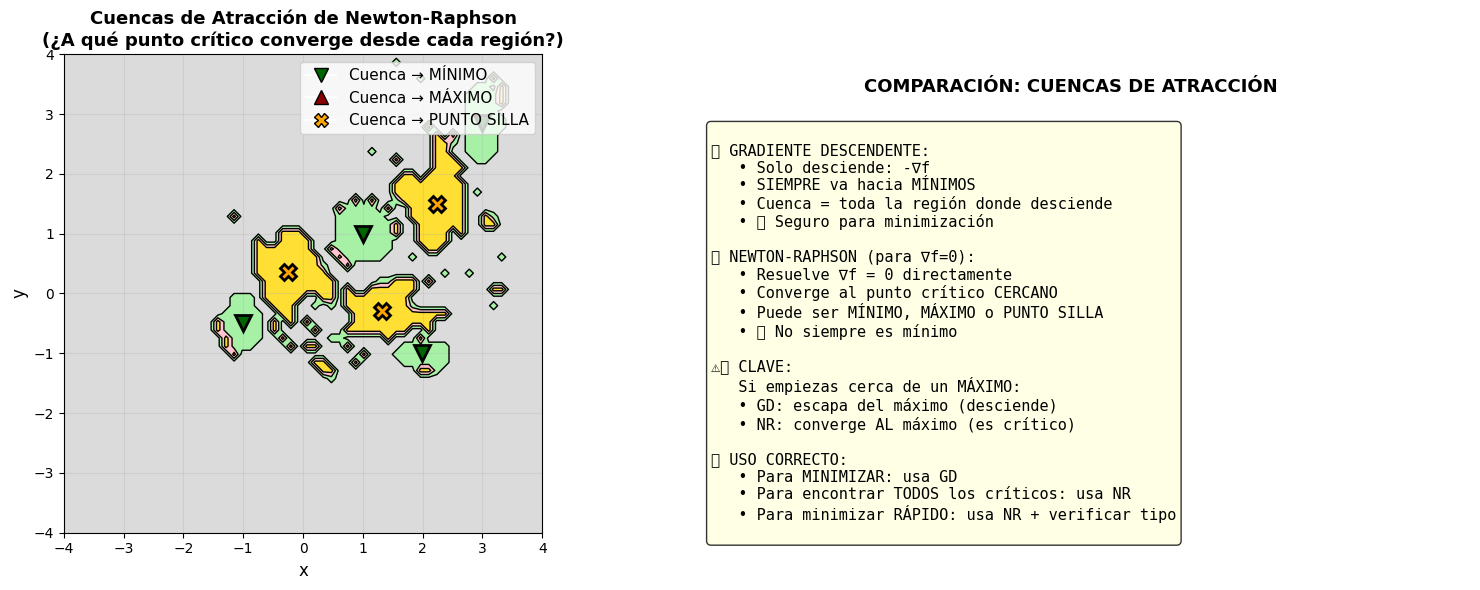

✓ Cuencas de atracción visualizadas

Puntos críticos encontrados: 1496
  (-2300.09, -54.01) → Inconcluso (det≈0)   f= -0.0000
  (-1674.24, 1046.52) → Inconcluso (det≈0)   f= -0.0000
  (-245.89, -96.07) → Inconcluso (det≈0)   f= -0.0000
  (-147.94, -342.20) → Inconcluso (det≈0)   f= -0.0000
  (-141.55, 42.73) → Inconcluso (det≈0)   f= -0.0000
  (-128.45, 9.53) → Inconcluso (det≈0)   f= -0.0000
  (-94.54, -6.34) → Inconcluso (det≈0)   f= -0.0000
  (-84.41, -72.31) → Inconcluso (det≈0)   f= -0.0000
  (-69.09, 49.05) → Inconcluso (det≈0)   f= -0.0000
  (-60.51, -68.41) → Inconcluso (det≈0)   f= -0.0000
  (-60.26, 2.29) → Inconcluso (det≈0)   f= -0.0000
  (-34.44, 9.41) → Inconcluso (det≈0)   f= -0.0000
  (-32.75, 19.38) → Inconcluso (det≈0)   f= -0.0000
  (-32.38, -0.88) → Inconcluso (det≈0)   f= -0.0000
  (-29.85, 2.33) → Inconcluso (det≈0)   f= -0.0000
  (-29.42, -18.01) → Inconcluso (det≈0)   f= -0.0000
  (-27.35, -25.54) → Inconcluso (det≈0)   f= -0.0000
  (-25.50, 1.73) → Inconcluso (

In [22]:
## Visualización: Cuencas de Atracción de Newton-Raphson

# Crear una malla más gruesa para calcular a dónde converge cada punto
print("\n⏳ Calculando cuencas de atracción de Newton-Raphson...")
print("   (esto puede tardarse un poco...)\n")

# Malla más gruesa para velocidad
x_basin = np.linspace(-4, 4, 60)
y_basin = np.linspace(-4, 4, 60)
X_basin, Y_basin = np.meshgrid(x_basin, y_basin)

# Para cada punto, determinar a qué punto crítico converge Newton-Raphson
basin_map = np.zeros(X_basin.shape)
critical_points_found = {}

for i in range(X_basin.shape[0]):
    for j in range(X_basin.shape[1]):
        x0, y0 = X_basin[i, j], Y_basin[i, j]
        
        # Aplicar Newton-Raphson desde este punto
        x, y = x0, y0
        for k in range(50):
            grad = gradient(x, y)
            if np.linalg.norm(grad) < 1e-5:
                break
            H = hessian(x, y)
            try:
                H_inv = np.linalg.inv(H)
            except:
                H += np.eye(2) * 1e-6
                H_inv = np.linalg.inv(H)
            delta = H_inv @ grad
            x = x - delta[0]
            y = y - delta[1]
        
        # Clasificar el punto crítico encontrado
        tipo, det_H, f_xx = clasificar_punto_critico(x, y)
        
        # Guardar información del punto crítico
        key = (round(x, 1), round(y, 1))
        if key not in critical_points_found:
            critical_points_found[key] = {
                'coords': (x, y),
                'tipo': tipo,
                'f': f(x, y),
                'det_H': det_H
            }
        
        # Asignar valor a la cuenca según el tipo de punto crítico
        if 'MÍNIMO' in tipo:
            basin_map[i, j] = 1  # Mínimo
        elif 'MÁXIMO' in tipo:
            basin_map[i, j] = 2  # Máximo
        elif 'SILLA' in tipo:
            basin_map[i, j] = 3  # Punto de silla
        else:
            basin_map[i, j] = 0  # Inconcluso

# Visualizar las cuencas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Cuencas de atracción codificadas por color
ax = axes[0]
im = ax.contourf(X_basin, Y_basin, basin_map, levels=[0, 0.5, 1.5, 2.5, 3.5], 
                  colors=['lightgray', '#90EE90', '#FFB6C1', '#FFD700'], alpha=0.8)
ax.contour(X_basin, Y_basin, basin_map, levels=[0.5, 1.5, 2.5, 3.5], colors='black', linewidths=1)

# Marcar los puntos críticos encontrados
for key, info in critical_points_found.items():
    x, y = info['coords']
    if 'MÍNIMO' in info['tipo']:
        ax.plot(x, y, 'v', color='darkgreen', markersize=12, markeredgecolor='black', markeredgewidth=2, label='Mínimo')
    elif 'MÁXIMO' in info['tipo']:
        ax.plot(x, y, '^', color='darkred', markersize=12, markeredgecolor='black', markeredgewidth=2, label='Máximo')
    elif 'SILLA' in info['tipo']:
        ax.plot(x, y, 'X', color='orange', markersize=12, markeredgecolor='black', markeredgewidth=2, label='Punto silla')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Cuencas de Atracción de Newton-Raphson\n(¿A qué punto crítico converge desde cada región?)', fontsize=13, fontweight='bold')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w', marker='v', markerfacecolor='darkgreen', markersize=10, 
           markeredgecolor='black', markeredgewidth=1, label='Cuenca → MÍNIMO'),
    Line2D([0], [0], color='w', marker='^', markerfacecolor='darkred', markersize=10,
           markeredgecolor='black', markeredgewidth=1, label='Cuenca → MÁXIMO'),
    Line2D([0], [0], color='w', marker='X', markerfacecolor='orange', markersize=10,
           markeredgecolor='black', markeredgewidth=1, label='Cuenca → PUNTO SILLA')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

# Gráfico 2: Comparación con Gradiente Descendente
ax = axes[1]
ax.text(0.5, 0.95, 'COMPARACIÓN: CUENCAS DE ATRACCIÓN', 
        ha='center', va='top', fontsize=13, fontweight='bold', transform=ax.transAxes)

comparison_text = """
🟢 GRADIENTE DESCENDENTE:
   • Solo desciende: -∇f
   • SIEMPRE va hacia MÍNIMOS
   • Cuenca = toda la región donde desciende
   • ✅ Seguro para minimización

🔴 NEWTON-RAPHSON (para ∇f=0):
   • Resuelve ∇f = 0 directamente
   • Converge al punto crítico CERCANO
   • Puede ser MÍNIMO, MÁXIMO o PUNTO SILLA
   • ❌ No siempre es mínimo

⚠️ CLAVE:
   Si empiezas cerca de un MÁXIMO:
   • GD: escapa del máximo (desciende)
   • NR: converge AL máximo (es crítico)

💡 USO CORRECTO:
   • Para MINIMIZAR: usa GD
   • Para encontrar TODOS los críticos: usa NR
   • Para minimizar RÁPIDO: usa NR + verificar tipo
"""

ax.text(0.05, 0.85, comparison_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Cuencas de atracción visualizadas\n")
print(f"Puntos críticos encontrados: {len(critical_points_found)}")
for key, info in sorted(critical_points_found.items()):
    x, y = info['coords']
    print(f"  ({x:.2f}, {y:.2f}) → {info['tipo']:20s} f={info['f']:8.4f}")
